In [82]:
import cirq
import matplotlib.pyplot as plt

In [83]:
#INITIAL CIRCUIT:

q0, q1, q2 = cirq.LineQubit.range(3)
a0, a1 = cirq.LineQubit.range(3, 5) #ancillas

circuit = cirq.Circuit()

#turning into the |+> state
circuit.append(cirq.H(q0))
    #first qubit now in superposition

#encoding one qubit onto three logical physical bits
circuit.append([cirq.CNOT(q0, q1), cirq.CNOT(q0, q2)])
    #after first CNOT: bell state
    #after second CNOT: a GHZ state/cat states/logical qubit for the 3-qubit code (codeword)
        ## final state at the end of the circuit ^^
        ## |000> + |111> / sqrt(2)

print(circuit)

0: ───H───@───@───
          │   │
1: ───────X───┼───
              │
2: ───────────X───


In [84]:
#INJECTING AN ERROR:

#error can be on any qubit
#here, on q1
circuit.append(cirq.X(q1))

print("After injecting an error on qubit 0: \n", circuit)

After injecting an error on qubit 0: 
               ┌──┐
0: ───H───@────@─────
          │    │
1: ───────X────┼X────
               │
2: ────────────X─────
              └──┘


In [85]:
#SYNDROME EXTRACTION:
#preparation of the encoder: involves taking raw qubits and preparing in a particular state

#parity between q0 and q1
circuit.append([cirq.CNOT(q0, a0), cirq.CNOT(q1, a0)])
#parity between q1 and q2
circuit.append([cirq.CNOT(q1, a1), cirq.CNOT(q2, a1)])

#measuring the ancilla qubits
circuit.append(cirq.measure(a0, key="syndrome1"))
circuit.append(cirq.measure(a1, key="syndrome2"))

#measuring the data qubits
circuit.append(cirq.measure(q0, q1, q2, key="data"))


#after 2nd CNOT, we have the codeword
#entanglement created for parity measurement:
    #to compare the ancillas to each other instead of seeing their values

print("full circuit (before any conditional gates): \n", circuit)

full circuit (before any conditional gates): 
               ┌──┐           ┌───────────────┐
0: ───H───@────@─────@───────────────────────────────M('data')────────
          │    │     │                               │
1: ───────X────┼X────┼───@────@──────────────────────M────────────────
               │     │   │    │                      │
2: ────────────X─────┼───┼────┼──────────────────@───M────────────────
                     │   │    │                  │
3: ──────────────────X───X────┼M('syndrome1')────┼────────────────────
                              │                  │
4: ───────────────────────────X──────────────────X───M('syndrome2')───
              └──┘           └───────────────┘


In [104]:
#SIMULATION:

sim = cirq.Simulator()
syndrome_result = sim.run(circuit, repetitions=1000)

syndrome1 = int(syndrome_result.measurements["syndrome1"][0][0])
syndrome2 = int(syndrome_result.measurements["syndrome2"][0][0])

syndrome = (syndrome1, syndrome2)
print(syndrome)

(1, 1)


In [105]:
#syndromes we would expect for error injected on each specific qubit
expected = {
    "none": (0, 0),
    "q0":   (1, 0),
    "q1":   (1, 1),
    "q2":   (0, 1)
}

expected_syndrome = expected["q1"]

print("expected syndrome: ", expected_syndrome)

if syndrome== expected_syndrome:
    print("syndrome detected")
else:
    print("wrong syndrome")

expected syndrome:  (1, 1)
syndrome detected


Counter({5: 501, 2: 499})


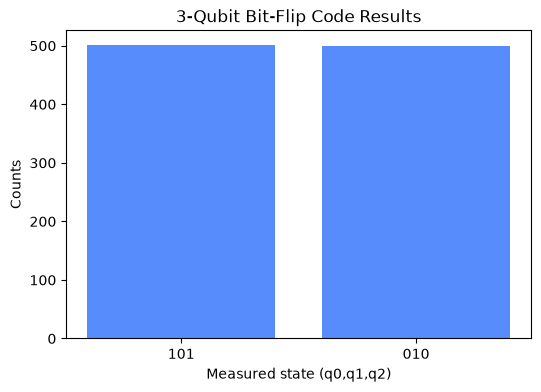

In [106]:
histogram = syndrome_result.histogram(key="data")
print(histogram)

labels = [format(state, '03b') for state in histogram.keys()] #keys from expected dictionary into labels
counts = list(histogram.values())

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.xlabel("Measured state (q0,q1,q2)")
plt.ylabel("Counts")
plt.title("3-Qubit Bit-Flip Code Results")
plt.show()